In [1]:
import pandas as pd

# Load the local CSV file into adataframe
df_aapl = pd.read_csv('../data/yfinance_data/AAPL.csv')

# Ensure the Date is a datetime object
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_aapl.set_index('Date', inplace=True)

print("AAPL data loaded from local file:")
print(df_aapl.head())

AAPL data loaded from local file:
               Close      High       Low      Open      Volume
Date                                                          
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800


In [2]:
import pandas as pd

# 1. Load the dataset
# Make sure the path matches where you saved the file (e.g., in data/stock_prices/)
df_aapl = pd.read_csv('../data/yfinance_data/AAPL.csv')

# 2. Set the Date as the index and ensure it's the right type
df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
df_aapl.set_index('Date', inplace=True)

# 3. Check for any missing values (NaN)
print("Missing values per column:")
print(df_aapl.isnull().sum())

# 4. Display the types to ensure they are numeric (float64 or int64)
print("\nColumn Data Types:")
print(df_aapl.dtypes)

# Preview the clean data
df_aapl.head()

Missing values per column:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Column Data Types:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
import talib
import pandas as pd
import yfinance as yf

In [4]:
import pandas as pd
import talib

# The path goes:
file_path = '../data/yfinance_data/AAPL.csv'

# Load it
df = pd.read_csv(file_path)

# Convert Date and set as index (important for time series)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print("Data loaded successfully!")
df.head()

Data loaded successfully!


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
# Calculate Technical Indicators
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])

# View the result
df[['SMA_20', 'EMA_20', 'RSI', 'MACD']].tail()

,SMA_20,EMA_20,RSI,MACD
Date,,,,
2023-12-22,191.856618,191.510231,54.672784,2.633141
2023-12-26,192.018094,191.484867,53.090049,2.304751
2023-12-27,192.154308,191.471353,53.354446,2.029104
2023-12-28,192.362839,191.499696,54.540999,1.823998
2023-12-29,192.490633,191.426275,51.121347,1.559539


In [6]:
# 1. Moving Averages (Windows of 20 and 50 days)
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

# 2. Relative Strength Index (14-day window)
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

# 3. MACD
# Returns: macd line, signal line, and the histogram (difference between them)
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'], 
                                                           fastperiod=12, 
                                                           slowperiod=26, 
                                                           signalperiod=9)

# --- THE OUTPUT COMMANDS ---
# This line tells the notebook to show the last 10 rows of your new calculations
df[['Close', 'SMA_20', 'EMA_20', 'RSI', 'MACD']].tail(10)

,Close,SMA_20,EMA_20,RSI,MACD
Date,,,,,
2023-12-15,195.721619,190.723320,190.396859,67.991716,3.745908
2023-12-18,194.057343,191.030421,190.745476,62.680148,3.582111
2023-12-19,195.097504,191.302353,191.159955,64.544428,3.495934
2023-12-20,193.007248,191.509893,191.335888,58.247457,3.221832
2023-12-21,192.858643,191.676816,191.480912,57.815603,2.958510
2023-12-22,191.788757,191.856618,191.510231,54.672784,2.633141
2023-12-26,191.243912,192.018094,191.484867,53.090049,2.304751
2023-12-27,191.342972,192.154308,191.471353,53.354446,2.029104
2023-12-28,191.768951,192.362839,191.499696,54.540999,1.823998


In [7]:
%matplotlib inline
import matplotlib.pyplot as plt
import talib

# 2a. Moving Averages (Multiple windows: 20 and 50)
df_aapl['SMA_20'] = talib.SMA(df_aapl['Close'], timeperiod=20)
df_aapl['EMA_20'] = talib.EMA(df_aapl['Close'], timeperiod=20)

# 2b. RSI (Identify Overbought/Oversold)
df_aapl['RSI_14'] = talib.RSI(df_aapl['Close'], timeperiod=14)

# 2c. MACD (Momentum shifts)
macd, macdsignal, macdhist = talib.MACD(df_aapl['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
df_aapl['MACD'] = macd
df_aapl['MACD_Signal'] = macdsignal
print(df_aapl.head())

               Close      High       Low      Open      Volume  SMA_20  \
Date                                                                     
2009-01-02  2.721686  2.730385  2.554037  2.575630   746015200     NaN   
2009-01-05  2.836553  2.884539  2.780469  2.794266  1181608400     NaN   
2009-01-06  2.789767  2.914229  2.770872  2.877641  1289310400     NaN   
2009-01-07  2.729484  2.774170  2.706990  2.753477   753048800     NaN   
2009-01-08  2.780169  2.793666  2.700393  2.712090   673500800     NaN   

            EMA_20  RSI_14  MACD  MACD_Signal  
Date                                           
2009-01-02     NaN     NaN   NaN          NaN  
2009-01-05     NaN     NaN   NaN          NaN  
2009-01-06     NaN     NaN   NaN          NaN  
2009-01-07     NaN     NaN   NaN          NaN  
2009-01-08     NaN     NaN   NaN          NaN  


In [8]:
# .tail() shows the last 5 rows, where calculations are finished
print(df_aapl.tail(10))

                 Close        High         Low        Open     Volume  \
Date                                                                    
2023-12-15  195.721619  196.543840  195.156944  195.681984  128538400   
2023-12-18  194.057343  194.790425  192.571376  194.255468   55751900   
2023-12-19  195.097504  195.107405  194.057324  194.324802   40714100   
2023-12-20  193.007248  195.830575  193.007248  195.057874   52242800   
2023-12-21  192.858643  195.236198  191.689689  194.265371   46482500   
2023-12-22  191.788757  193.581821  191.164647  193.353962   37149600   
2023-12-26  191.243912  192.076049  191.025969  191.798670   28919300   
2023-12-27  191.342972  191.689703  189.302247  190.689158   48087700   
2023-12-28  191.768951  192.838849  191.362784  192.323710   34049900   
2023-12-29  190.728775  192.581275  189.936256  192.085953   42672100   

                SMA_20      EMA_20     RSI_14      MACD  MACD_Signal  
Date                                                

In [9]:
# Drop the first few rows that have NaN because the indicators were still "warming up"
df_aapl.dropna(inplace=True)

# Now check the head again - the NaNs will be gone!
print(df_aapl.head())

               Close      High       Low      Open     Volume    SMA_20  \
Date                                                                      
2009-02-20  2.735183  2.771173  2.669203  2.681199  750316000  2.829070   
2009-02-23  2.607722  2.759177  2.594526  2.748680  786982000  2.826956   
2009-02-24  2.706692  2.725886  2.609221  2.622717  807105600  2.827870   
2009-02-25  2.733984  2.786768  2.676701  2.694996  833053200  2.828515   
2009-02-26  2.674901  2.786768  2.668004  2.759176  629868400  2.821003   

              EMA_20     RSI_14      MACD  MACD_Signal  
Date                                                    
2009-02-20  2.811611  45.273764  0.049638     0.085309  
2009-02-23  2.792193  39.355300  0.028595     0.073966  
2009-02-24  2.784050  45.331284  0.019677     0.063109  
2009-02-25  2.779281  46.885613  0.014644     0.053416  
2009-02-26  2.769341  43.971002  0.005820     0.043896  


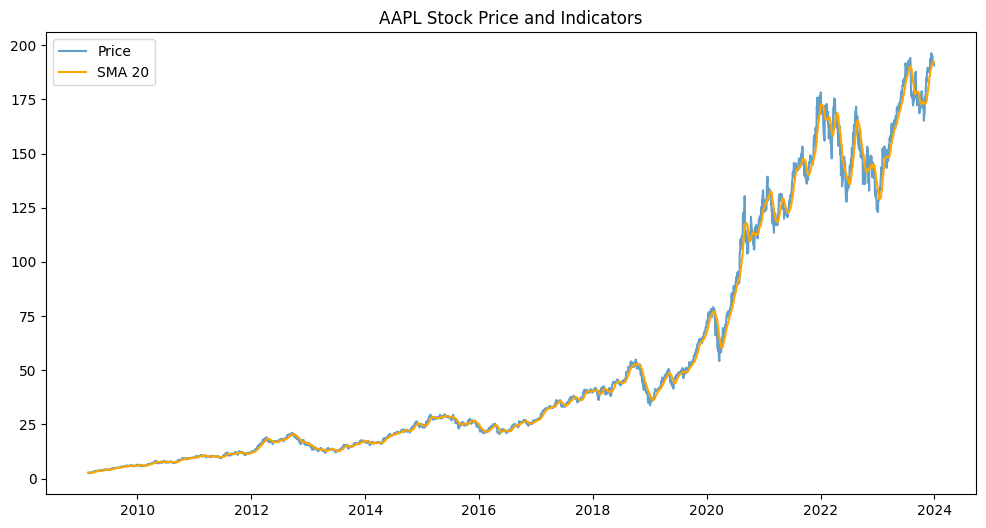

In [10]:
import matplotlib.pyplot as plt

# Step A: Drop the NaN rows so the plotter doesn't get confused
df_clean = df_aapl.dropna()

# Step B: Tell VS Code to show the plot inside the notebook
%matplotlib inline

# Step C: Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_clean.index, df_clean['Close'], label='Price', alpha=0.7)
plt.plot(df_clean.index, df_clean['SMA_20'], label='SMA 20', color='orange')

plt.title('AAPL Stock Price and Indicators')
plt.legend()

# Step D: THE MOST IMPORTANT LINE
plt.show()

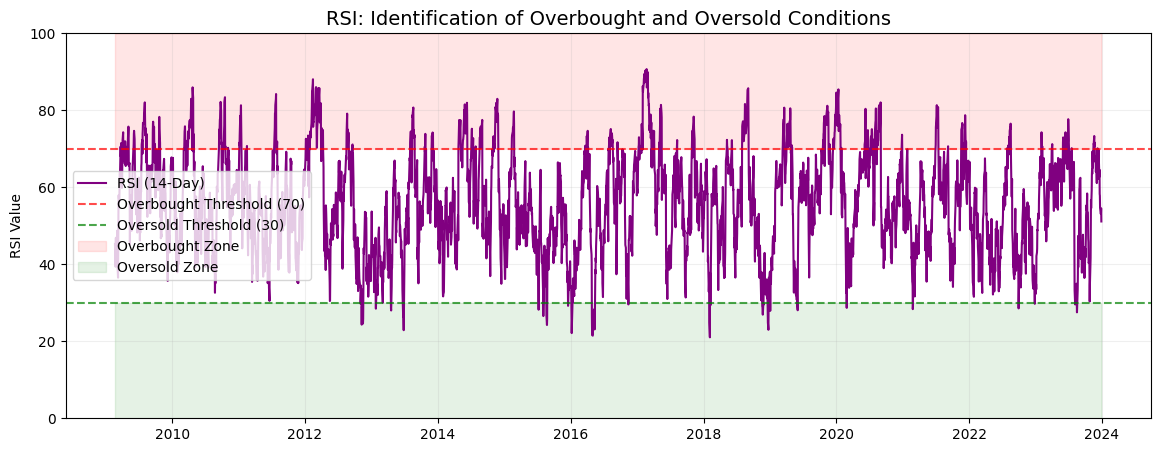

In [11]:
import matplotlib.pyplot as plt

# 1. Clean the data to remove NaN values from the beginning
df_rsi = df_aapl[['RSI_14']].dropna()

# 2. Create the chart
plt.figure(figsize=(14, 5))

# Plot the RSI line
plt.plot(df_rsi.index, df_rsi['RSI_14'], label='RSI (14-Day)', color='purple', linewidth=1.5)

# 3. IDENTIFY CONDITIONS: Add horizontal threshold lines
plt.axhline(70, color='red', linestyle='--', alpha=0.7, label='Overbought Threshold (70)')
plt.axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold Threshold (30)')

# 4. Fill the background zones for clear identification (Task 4c)
plt.fill_between(df_rsi.index, 70, 100, color='red', alpha=0.1, label='Overbought Zone')
plt.fill_between(df_rsi.index, 0, 30, color='green', alpha=0.1, label='Oversold Zone')

# Formatting
plt.title('RSI: Identification of Overbought and Oversold Conditions', fontsize=14)
plt.ylabel('RSI Value')
plt.ylim(0, 100) # RSI is always between 0 and 100
plt.legend(loc='best')
plt.grid(True, alpha=0.2)

plt.show()

In [12]:
# Print the last 5 times AAPL was overbought
print("Latest Overbought Dates Identified:")
print(df_aapl[df_aapl['RSI_14'] > 70].tail())

Latest Overbought Dates Identified:
                 Close        High         Low        Open    Volume  \
Date                                                                   
2023-11-17  187.915329  188.598876  186.805812  188.470087  50922700   
2023-11-20  189.658859  190.114562  188.103555  188.113456  46505100   
2023-11-21  188.856445  189.728217  187.964871  189.619246  38134500   
2023-11-22  189.520187  191.125027  189.044682  189.698511  39617700   
2023-12-08  193.879013  194.156392  191.858090  192.383130  53406400   

                SMA_20      EMA_20     RSI_14      MACD  MACD_Signal  
Date                                                                  
2023-11-17  176.883460  179.898019  71.178679  3.655271     2.202632  
2023-11-20  177.808603  180.827623  73.312524  3.958127     2.553731  
2023-11-21  178.671861  181.592273  70.717568  4.086291     2.860243  
2023-11-22  179.684058  182.347312  71.612649  4.193085     3.126811  
2023-12-08  188.485949  187.60060

In [13]:
import talib

# 2c. Calculate MACD
# Standard periods: Fast=12, Slow=26, Signal=9
macd, macdsignal, macdhist = talib.MACD(df_aapl['Close'], 
                                        fastperiod=12, 
                                        slowperiod=26, 
                                        signalperiod=9)

df_aapl['MACD'] = macd
df_aapl['MACD_Signal'] = macdsignal
df_aapl['MACD_Hist'] = macdhist

print("MACD Calculation Complete!")

MACD Calculation Complete!


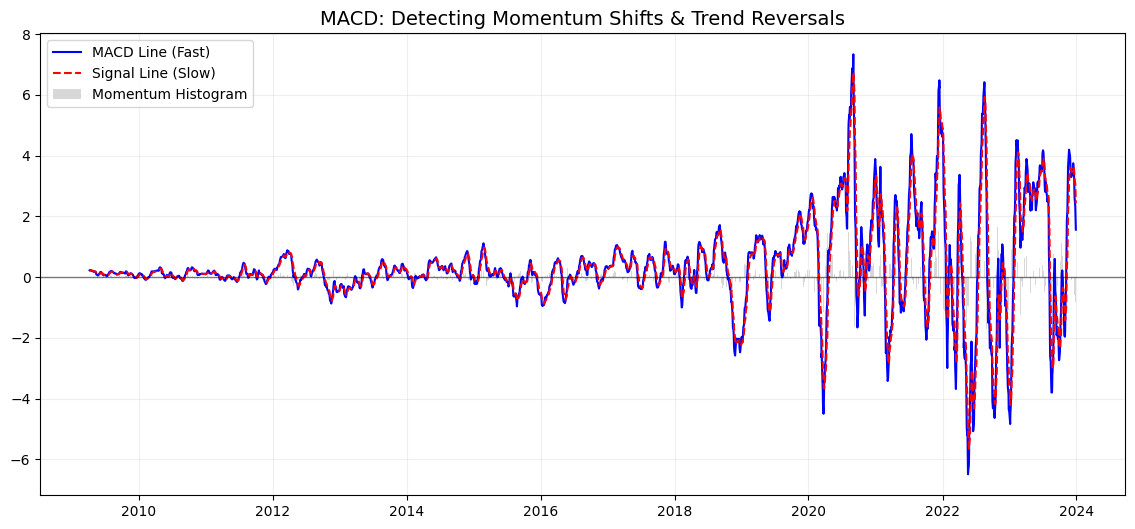

In [14]:
import matplotlib.pyplot as plt

# Drop NaNs created by the 26-day calculation period
df_macd = df_aapl.dropna()

plt.figure(figsize=(14, 6))

# Plot MACD Line and Signal Line
plt.plot(df_macd.index, df_macd['MACD'], label='MACD Line (Fast)', color='blue')
plt.plot(df_macd.index, df_macd['MACD_Signal'], label='Signal Line (Slow)', color='red', linestyle='--')

# Plot the Histogram (Momentum bars)
plt.bar(df_macd.index, df_macd['MACD_Hist'], label='Momentum Histogram', 
        color='gray', alpha=0.3)

# Add a Zero Line - the "Neutral" point
plt.axhline(0, color='black', linewidth=1, alpha=0.5)

plt.title('MACD: Detecting Momentum Shifts & Trend Reversals', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.2)
plt.show()

In [15]:
import pynance as pn

# 3. Compute Financial Metrics
# Daily Returns: The percentage change in price each day
df_aapl['Daily_Return'] = df_aapl['Close'].pct_change()

# Cumulative Returns: The total return since the beginning of the dataset
df_aapl['Cumulative_Return'] = (1 + df_aapl['Daily_Return']).cumprod() - 1

# Volatility (Rolling Standard Deviation of returns)
# This shows how "risky" or "jumpy" the stock is
df_aapl['Volatility'] = df_aapl['Daily_Return'].rolling(window=20).std()

print("PyNance Financial Metrics Computed!")
print(df_aapl[['Daily_Return', 'Cumulative_Return', 'Volatility']].tail())

PyNance Financial Metrics Computed!
            Daily_Return  Cumulative_Return  Volatility
Date                                                   
2023-12-22     -0.005548          69.119156    0.009071
2023-12-26     -0.002841          68.919957    0.009103
2023-12-27      0.000518          68.956174    0.009086
2023-12-28      0.002226          69.111915    0.008973
2023-12-29     -0.005424          68.731620    0.009078


✅ Data Loaded: ../data/yfinance_data/AAPL.csv


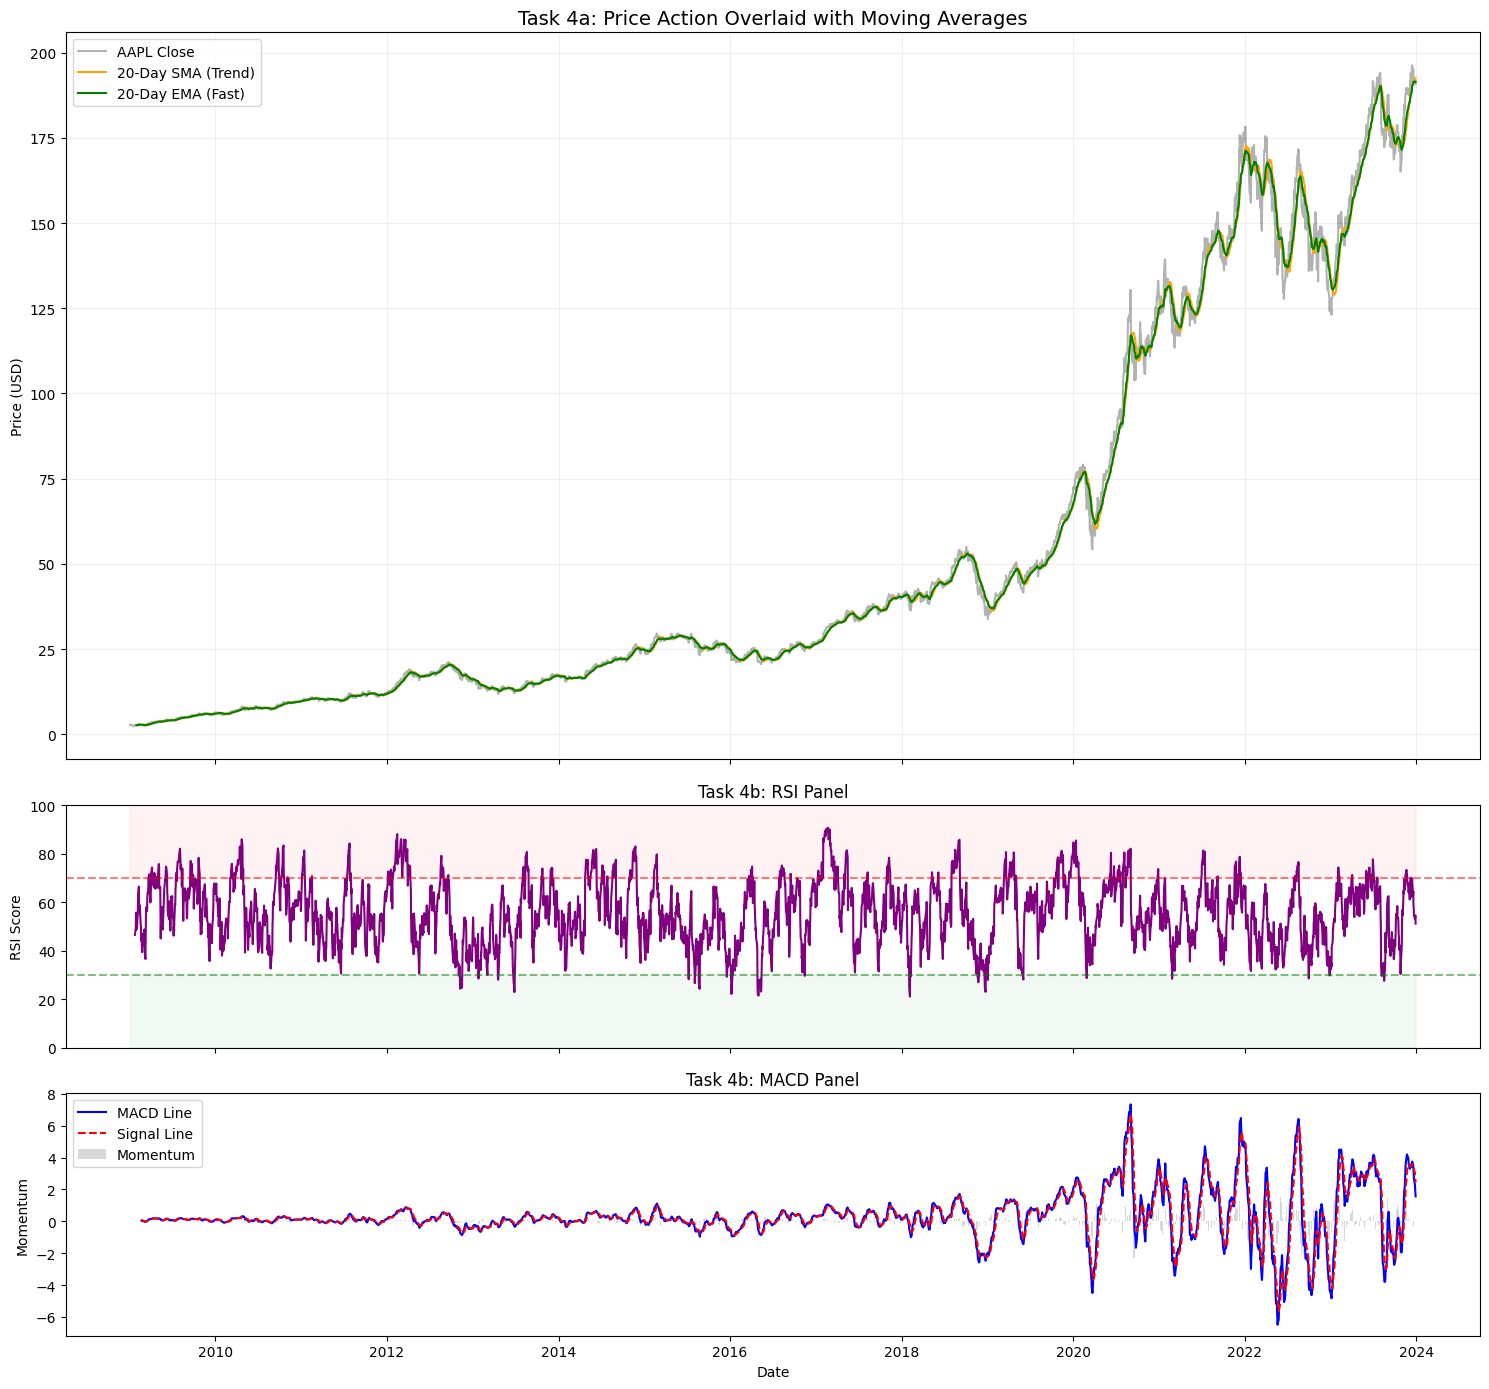

In [ ]:
import pandas as pd
import talib
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. LOAD ASSIGNED DATA (Using the correct relative path)
file_path = '../data/yfinance_data/AAPL.csv'

if os.path.exists(file_path):
    df = pd.read_csv(file_path, parse_dates=True, index_col=0)
    df.columns = df.columns.str.strip()
    print(f"✅ Data Loaded: {file_path}")
else:
    # Backup path if you are running outside the notebooks folder
    df = pd.read_csv('data/yfinance_data/AAPL.csv', parse_dates=True, index_col=0)

# 2. CALCULATE ALL INDICATORS (Tasks 2 & 3)
close = df['Close'].ffill()

# Moving Averages
df['SMA_20'] = talib.SMA(close, timeperiod=20)
df['EMA_20'] = talib.EMA(close, timeperiod=20)

# RSI
df['RSI_14'] = talib.RSI(close, timeperiod=14)

# MACD
macd, macdsignal, macdhist = talib.MACD(close)
df['MACD'] = macd
df['MACD_Signal'] = macdsignal
df['MACD_Hist'] = macdhist

# 3. CREATE THE 3-PANEL VISUALIZATION (Task 4)
# sharex=True ensures that zooming in on one chart zooms the others too
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 14), sharex=True, 
                                     gridspec_kw={'height_ratios': [3, 1, 1]})

# --- Panel 1: Price Action & Moving Averages ---
ax1.plot(df.index, df['Close'], label='AAPL Close', color='black', alpha=0.3)
ax1.plot(df.index, df['SMA_20'], label='20-Day SMA (Trend)', color='orange', lw=1.5)
ax1.plot(df.index, df['EMA_20'], label='20-Day EMA (Fast)', color='green', lw=1.5)
ax1.set_title('Task 4a: Price Action Overlaid with Moving Averages', fontsize=14)
ax1.set_ylabel('Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.2)

# --- Panel 2: RSI (Relative Strength) ---
ax2.plot(df.index, df['RSI_14'], color='purple', lw=1.5)
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
ax2.fill_between(df.index, 70, 100, color='red', alpha=0.05)
ax2.fill_between(df.index, 0, 30, color='green', alpha=0.05)
ax2.set_title('Task 4b: RSI Panel', fontsize=12)
ax2.set_ylabel('RSI Score')
ax2.set_ylim(0, 100)

# --- Panel 3: MACD (Momentum) ---
ax3.plot(df.index, df['MACD'], label='MACD Line', color='blue')
ax3.plot(df.index, df['MACD_Signal'], label='Signal Line', color='red', linestyle='--')
ax3.bar(df.index, df['MACD_Hist'], label='Momentum', color='gray', alpha=0.3)
ax3.set_title('Task 4b: MACD Panel', fontsize=12)
ax3.set_ylabel('Momentum')
ax3.legend(loc='upper left')

plt.xlabel('Date')
plt.tight_layout()
plt.show()